<a href="https://colab.research.google.com/github/lukasz23g/Machine-Learning-2026/blob/main/ML_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning - Final Project
## Project author: Łukasz Grzegrzółka

#### Project from: Lab 12 - Towards Self-Attention (*pl. Samoatencja*), original notebook author: Szymon Nowakowski


# **Last Homework – Finding Odd Shapes**

To accommodate this year semester schedule changes, students in all groups receive a **larger homework assignment for Class 12**.

## **RULES**

### **Deadline**

**The deadline for this homework is *3 weeks* from the class date:**
- Wednesday group (group 1): June 10th
- Monday group (group 2): June 22th


### **Grading Criteria**

This homework will be graded on a scale from 0 to 4 points - plus a **bonus**.

- **4 points** (equivalent to completing two homework assignments worth 2 points each):
  - **the solution must attain an RMSE of 5.0 pixels or lower** (on 25,000 samples).
  - the sizes of all tensors must be annotated in comments
  - training loss curve must be plotted with a clear indication of a 5.0 pixels level
  - an in-depth textual description of the solution must be provided
  - clear attention charts with discussion must be included

- **3 points** (equivalent to completing one homework assignment worth 2 points and the second one with only an incomplete solution):
  - training loss curve must be plotted with a clear indication of a 5.0 pixels level
  - the sizes of all tensors must be annotated in comments
  - an in-depth textual description of the solution must be provided
  - clear attention charts with discussion must be included

- **2 points** (equivalent to completing one homework assignment worth 2 points):
  - missing any one of the following elements:
    - training loss curve plot with a clear indication of a 5.0 pixels level
    - tensor size annotations in comments
    - in-depth textual description of the solution
    - attention charts with discussion

- **1 point** (equivalent to submitting an incomplete homework assignment):
  - missing any two of the following elements:
    - training loss curve plot with a clear indication of a 5.0 pixels level
    - tensor size annotations in comments
    - in-depth textual description of the solution
    - attention charts with discussion

- **0 points** (equivalent to not completing the homework assignment):
  - missing any three of the following:
    - training loss curve plot with a clear indication of a 5.0 pixels level
    - tensor size annotations in comments
    - in-depth textual description of the solution
    - attention charts with discussion

- **BONUS** – This homework encompasses all key elements from previous classes on deep neural networks.  
As a result, any student who obtains an **RMSE of 3.0 pixels or below** (on 25,000 samples), and whose solution would otherwise qualify for 4 points, **will receive the full 14 points** — equivalent to completing all homework assignments related to deep learning — regardless of their previous scores.



## **HOMEWORK ASSIGNMENT DESCRIPTION AND INSTRUCTIONS**

### **Online Dataset**

The code provided below generates an *online* dataset `OddXYDataset`.

The term *online* means that the dataset does not have a fixed set of pre-generated examples (like a traditional training set of fixed size). Instead, new samples are generated dynamically each time they are requested.

While the number of possible examples is finite in principle, it is so large that — for practical purposes — we can consider it to be effectively infinite.

In this setting, there is no need to use a separate validation or test set: the training error itself is a good estimate of the generalization error, since every training sample is new and unseen.

Consequently, the notion of an *epoch* becomes a matter of convention. For this assignment, we define one epoch as processing 25,000 training examples.

### **Training strategies**

Overfitting is not a problem in the *online* setting — but training can still stagnate in local minima or flat regions of the loss landscape.  
To address this, you will likely need to try one or more of the following strategies:

- **Multiple restarts** with different random seed values;
- **Adaptive learning rate** — consider researching training schedulers (this topic was not covered in class);
- **Progressive model growth** — start with a simpler architecture and gradually add components during training,
  so that the parts already present can learn what to do before the rest is introduced.

### **DataLoader**

The `show_examples()` function demonstrate how to wrap the dataset into a `torch.utils.data.DataLoader` so it becomes directly usable for the training/testing of a neural network.

### **Data Description**

By examining the provided code and a few sample images generated from this dataset, you will notice that:

1. **Each data sample** is a 64×64 black-and-white image with the following characteristics:
  - It contains several shapes of the same type (either circles, triangles, or squares), randomly placed and varying in size;
  - It includes one additional shape of a different type — the *odd* shape — also placed at a random location;
  
  **Note that these shapes may overlap partially or even completely, potentially hiding the odd shape.**

2. **The label** associated with each image is a 2D point indicating the coordinates of the center of the odd shape.

### **The Homework Objective**

Students should design an architecture of an **attention-based neural network** and train it so that it attains an RMSE (Root Mean Square Error, defined as the square root of the MSE) of **5.0 or lower**. Due to the nature of the online dataset, there is no need to test the solution on a separate test set.

Students should visualize the attention matrices in the trained network and **discuss what they observe** — not just describe them.  
Focus on interpreting the patterns: Where is the model attending? Are there any consistent behaviors across samples? Does attention correlate with the position of the odd shape? What do surprising or unclear patterns tell us?

A few technical requirements to observe:

- Seed all random number generators so that (1) your results are replicable and (2) I can rerun your solution and obtain the same output — *in case I need to check something*.

- Make sure your Colab file contains a **fully trained solution** with:
  - printed training output,
  - attention diagrams,
  - and a plot of the training loss curve.

This way, I don't have to rerun your code unless absolutely necessary.

### **Publish on GitHub**
- Upload your Colab notebook to your **GitHub repository** for this course.
- In your repository's **README**, include a **link** to the notebook.
- In the notebook include **“Open in Colab”** badge so the notebook can be launched directly from GitHub.

## **SOLUTION SUGGESTIONS**

Students **do not need to follow these suggestions** — these are simply the strategies that worked for me.

The goal of the homework is, of course, to find the location of the odd shape. For that reason, it seems worthwhile to consider a *position-aware* variant of the post-processing of attention results. The solution I propose consists of the following components:


0. **Input**  
   Our input is a black-and-white image with 1 channel, of size 64×64 pixels.

1. **Embedding**  
  In class, we embedded a sequence of tokens in a multidimensional space, resulting in a sequence of embeddings. We also saw how such sequences are compatible with positional encoding and attention mechanisms used in subsequent stages.

  Here, we need to process an image that contains shapes of interest at various spatial locations.  
  To do this, I designed a Convolutional Neural Network with:
  - 1 input channel,
  - an input grid of 64x64 pixels,
  - and an output feature map arranged as a 12x12 pixel grid with 16 channels.

  I used **no padding**, and each output neuron/pixel has a **receptive field of size 20x20** with a **stride of 4x4**.  
  This architectural choice yields **144 distinct positions** (12x12), each represented by a 16-dimensional feature vector.

  We can treat this as a sequence of 144 embeddings in 16-dimensional space — making it fully compatible with the attention mechanisms used later in the model.


2. **Positional Encoding**  
  I applied sinusoidal positional encoding, just like in class, using 16 positional dimensions to match the 16 feature dimensions of the image embeddings.  

  Positions were encoded based on their indices from 0 to 143.

3. **Attention**  
   I used full self-attention, where input tokens are linearly projected into Query, Key, and Value vectors using learned matrices.

4. **Post-Processing**  
   The classifier was implemented as a 2-layer MLP and applied **token-wise**, without averaging over positions.  

   This corresponds to the **position-aware** variant of post-processing the attention results, as discussed in class.

   As a result, the model produced a **logit for each of the 144 spatial locations**, which was then converted with `softmax` into a **probability distribution** over positions — representing the likelihood of the odd shape being located at each position.


5. **Final Prediction**  
   We know the exact position (center) of each of the 144 rectangular receptive fields of the embedding network. Since we also have the **probability** of each field being the target location (from the classifier), we can compute the **expected position** as a weighted average of receptive field centers. In what follows I will call it *soft argmax*.

   **Example:**

   Suppose we had only 4 output rectangles (instead of 144), with centers at:  
   $$(16, 16),\ (16, 48),\ (48, 16),\ \text{and } (48, 48).$$  
   and suppose the probabilities from the post-processing stage were:  
   $$(0.1,\ 0.2,\ 0.69999,\ 0.00001).$$  
   Then the predicted center would be:
   $$
   \begin{align*}
   x &= 16 \cdot 0.1 + 16 \cdot 0.2 + 48 \cdot 0.69999 + 48 \cdot 0.00001 \\
   y &= 16 \cdot 0.1 + 48 \cdot 0.2 + 16 \cdot 0.69999 + 48 \cdot 0.00001
   \end{align*}
   $$

   which yields an interpretable, differentiable prediction for the (x, y) location of the odd shape (*soft argmax*).

**The above steps bring the RMSE below 4.0 pixels.**  
However, the result depends on the network initialization — it is seed-dependent — so it's worth restarting the training a few times with different seeds to find a better-performing run.

To improve this result further, though, we'll have to work a bit harder. Here's how:


6. **Offset Regressor**

  The soft-argmax mechanism in step 5 identifies the **center** of the most probable receptive field, but it cannot fine-tune the prediction within that field. For example, if the odd shape is located in the **lower-left corner** of a receptive field, the best the model can do is predict the **center** of that rectangle — introducing a systematic error.

  *One may argue:* the design naturally accounts for a more nuanced case. When the odd shape lies **across the boundary between two receptive fields**, the attention distribution may spread across both regions. In such cases, the soft-argmax prediction becomes a **weighted average** of the centers of the adjacent fields. This behavior is a built-in **feature of the design** that allows the model to predict positions **off-center**, somewhere in between fields.

  *To that I would reply:* this is true — but it comes with a trade-off. When attention is distributed across multiple regions, it becomes **less clear which shapes are *regular* and which one is *odd***. This added ambiguity may make it harder for the network to reach a confident decision, especially in the early stages of training.

  To address this systematic limitation in a more structured way, I introduced an additional **2-layer MLP regressor**, applied **token-wise** to each of the 144 positions. This regressor takes the same attention output used by the classifier in step 4 and predicts a **local offset** $(\Delta x, \Delta y)$ within each receptive field. These offsets are then **aggregated** using the probabilities from step 4, resulting in a **soft average correction vector**.

  Note that the attention mechanism must learn to extract — from the original features — both:
  - the **probability** that the odd shape is located at a given position, and  
  - the **local coordinates** of that shape *within* the respective receptive field.


7. **Refined Prediction**

  The final predicted position is obtained by summing the **coarse prediction** from step 5 and the **fine-grained correction** from step 6. This allows the model to make accurate, differentiable predictions at **sub-receptive-field resolution**, resulting in significantly improved localization.

  **In summary:**

  - Step 5: predicts the expected center of the relevant receptive field (via soft-argmax);
  - Step 6: estimates a fine-grained, attention-weighted offset within that field;
  - Step 7: adds both components to produce the final prediction:

$$
\text{final prediction} = \underbrace{\sum_i p_i \cdot C_i}_{\text{soft argmax}} + \underbrace{\sum_i p_i \cdot (\Delta x, \Delta y)_i}_{\text{fine correction offset}}
$$


However, I was not able to train this network end-to-end from scratch — it seems that the two heads (the classifier inferring probabilities and the regressor inferring fine-grained corrections) were not able to learn their roles *simultaneously*.  

To solve this, I adopted a **progressive model growth** training strategy:

- First, I trained a one-headed version of the network (without steps 6 and 7) until the RMSE reached approximately 4.0 — a clear indication that the probability distribution was being inferred correctly.
- Then, I copied all weights into a new, complete two-headed network and continued training from that point.

**This strategy brought the RMSE down to 2.65 pixels.**


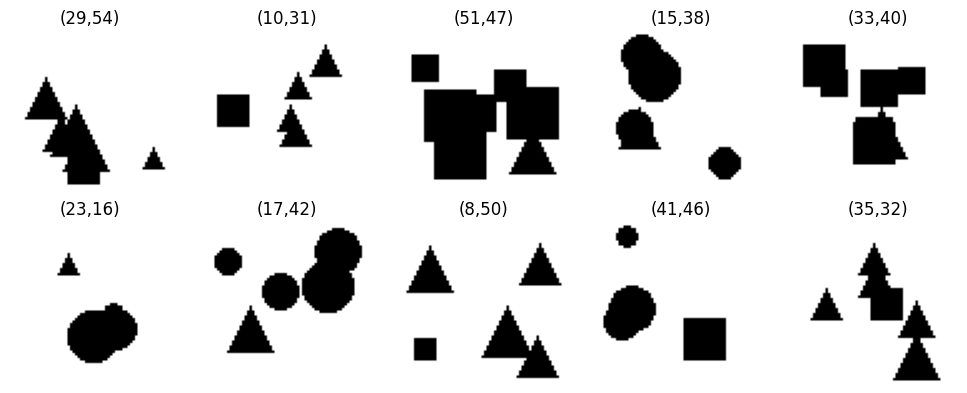

In [ ]:
# ============================================================
# 0. Imports & device
# ============================================================
import torch, random, math, numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 1. Online dataset: 64×64, target = (cx,cy) ∈ [0,63]²  (float32)
# ============================================================
IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
    if shape_type == "circle":
        drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
    elif shape_type == "square":
        drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
    else:  # triangle
        drawer.polygon([
            (center_x, center_y - radius),
            (center_x - radius, center_y + radius),
            (center_x + radius, center_y + radius)
        ], fill="black")

class OddXYDataset(Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    Arguments:
        num_samples             – total number of samples in the dataset
        same_shape_count_range – tuple (min, max), number of identical shapes
        shape_radius_range      – tuple (min_radius, max_radius) for shape size
    """
    def __init__(self,
                 num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
        self.num_samples = num_samples
        self.same_shape_count_range = same_shape_count_range
        self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        base_shape = random.choice(SHAPES)
        odd_shape = random.choice([s for s in SHAPES if s != base_shape])

        img = Image.new("L", (IMAGE, IMAGE), "white")
        drawer = ImageDraw.Draw(img)

        # draw identical shapes
        for _ in range(random.randint(*self.same_shape_count_range)):
            radius = random.randint(self.radius_min, self.radius_max)
            cx = random.randint(radius, IMAGE - radius - 1)
            cy = random.randint(radius, IMAGE - radius - 1)
            draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, odd_shape, cx, cy, radius)

        img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.
        label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)
        return img_tensor, label_tensor

def show_examples(num_examples=10):
    """
    Displays a grid of image samples from OddXYDataset using a DataLoader with batch_size=1.

    Args:
        num_examples (int): Number of examples to display.
    """
    dataset = OddXYDataset(num_samples=num_examples)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    num_columns = 5
    num_rows = math.ceil(num_examples / num_columns)

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

    for i, (image, label) in enumerate(dataloader):
        if i >= num_examples:
            break
        image_np = image.squeeze(0).squeeze(0).numpy()  # B=1,C=1,H,W --> H,W
        cx, cy = label.squeeze(0)                       # B=1,2       --> 2
        axes.flat[i].imshow(image_np, cmap="gray")
        axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
        axes.flat[i].axis("off")

    for j in range(i + 1, num_rows * num_columns):
        axes.flat[j].axis("off")

    plt.tight_layout()
    plt.show()



show_examples()

## Helpeful Functions:

`train_model(net, epochs, lr)`

This function trains the neural network on 25,000 freshly generated samples per epoch. It uses `Adam` optimizer for weight updates, `MSE loss` between predicted and true (x, y) coordinates `RMSE` as the main performance metric.

For each epoch a new online dataset is created and the model is trained on it. After each epoch `RMSE` is computed and stored. The function returns a list of RMSE values, one per epoch, which is later used to plot the training curve.

`test_model(net, num_samples)`

This function evaluates the model without dropout and without gradient computation. It generates a new dataset of `num_samples` examples. Then it runs the model once over all samples and omputes the final RMSE. This gives a stable estimate of the model’s performance.

`plot_rmse_curve(train_rmse_history)`

This function plots the RMSE values collected during training. The plot includes the RMSE curve, a red dashed line at 5.0 px (the homework requirement) and a green dotted line at 3.0 px (bonus threshold). This makes it easy to see whether the model meets the assignment goals.

`compute_centers()`

This function computes the (x, y) coordinates of the centers of all 196 receptive fields produced by the CNN embedding. The CNN produces a 14×14 grid of tokens, each of which corresponds to a patch in the original 64×64 image.

The center of each patch is computed using:

- start = 6.0 - the center of the first receptive field,
- jump = 4.0 - how far the center moves when we go to the next token,
- size = 14 - number of tokens along each dimension.

Hence, the center of token (i, j) is:

- cx = start + j * jump,
- cy = start + i * jump.

The function returns a tensor of shape (196, 2).

`soft_argmax(probs, centers)`

This function computes the expected position of the odd shape using the soft-argmax function. It multiplies `probs[i]` (the probability that the odd shape is in token i) and `centers[i]` (the (x, y) center of that token). Then sums over all tokens:

$$ \text{prediction} = \sum_i p_i \cdot C_i $$

This gives a smooth, differentiable version of argmax.

`set_seed(seed)`

This function sets all random seeds:

- Python random
- NumPy
- PyTorch (CPU and GPU)

This ensures that the training is reproducible and the results can be verified anytime in the future.

In [ ]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")


def train_model(net, epochs=1, lr=0.001, log_every=1):
    print(f"Working on {device}")
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    # Mean Squared Error
    criterion = torch.nn.MSELoss()

    train_rmse_history = []
    start_time = time.time()

    for epoch in range(epochs):
        net.train()
        set_seed(epoch)

        dataset = OddXYDataset(num_samples=25000)
        dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

        train_mse_sum = 0.0
        train_total = 0

        for batch_inputs, batch_labels in dataloader:
            batch_inputs = batch_inputs.to(device)          # [Batch_Size, 1, 64, 64]
            batch_labels = batch_labels.to(device).float()  # [Batch_Size, 2] - (cx, cy)

            optimizer.zero_grad()

            # (final_prediction, attention_weights)
            predictions, _, _ = net(batch_inputs)              # [Batch_Size, 2]

            loss = criterion(predictions, batch_labels)
            loss.backward()
            optimizer.step()

            train_mse_sum += loss.item() * batch_inputs.size(0)
            train_total += batch_inputs.size(0)

        # calculate mean MSE, then take square root
        avg_train_mse = train_mse_sum / train_total
        avg_train_rmse = math.sqrt(avg_train_mse)

        train_rmse_history.append(avg_train_rmse)

        if epoch % log_every == 0:
            print(f"Epoch {epoch:02d} | Train RMSE: {avg_train_rmse:.2f} pixels")

    end_time = time.time()
    print(f"Elapsed time: {end_time - start_time:.2f} seconds")

    return train_rmse_history


def test_model(net, num_samples=25000):
    net.eval()  # switch off dropout and batchnorm

    dataset = OddXYDataset(num_samples=num_samples)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

    mse_sum = 0.0
    total = 0

    with torch.no_grad():  # no gradients
        for batch_inputs, batch_labels in dataloader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device).float()

            preds, _, _ = net(batch_inputs)

            mse = torch.mean((preds - batch_labels) ** 2, dim=1)
            mse_sum += mse.sum().item()
            total += batch_inputs.size(0)

    rmse = math.sqrt(mse_sum / total)
    print(f"Test RMSE: {rmse:.3f} px")

    return rmse



def plot_rmse_curve(train_rmse_history):
    plt.figure(figsize=(8, 5))
    plt.plot(train_rmse_history, label="Train RMSE", color='blue', linewidth=2)

    # basic level
    plt.axhline(y=5.0, color='red', linestyle='--', label="Target Level (5.0 px)")

    # bonus level
    plt.axhline(y=3.0, color='green', linestyle=':', label="Bonus Level (3.0 px)")

    plt.title("Model Performance (RMSE) per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE (Pixels)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

def compute_centers():
    centers = []

    start = 6.0   # first field center
    jump  = 4.0   # effective stride
    size  = 14    # 14x14 tokens

    for i in range(size):
        for j in range(size):
            cx = start + j * jump
            cy = start + i * jump
            centers.append((cx, cy))

    return torch.tensor(centers, dtype=torch.float32)  # (196, 2)


def soft_argmax(probs, centers):
    return (probs.unsqueeze(-1) * centers).sum(dim=1)  # (B, 2)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


Working on cuda


In [ ]:
import torch
import torch.nn as nn
import math

class ImageEmbeddingCNN(nn.Module):
    def __init__(self, out_channels=32):
        super().__init__()
        # two cnn layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=12, stride=2, padding=3, padding_mode="reflect")
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=out_channels, kernel_size=6, stride=2, padding=1, padding_mode="reflect")
        self.activation = nn.GELU()

    def forward(self, x):
        # input: [Batch_Size, 1, 64, 64]
        x = self.conv1(x)          # [Batch_Size, 16, 30, 30]
        x = self.activation(x)    # [Batch_Size, 16, 30, 30]
        x = self.conv2(x)          # [Batch_Size, 32, 14, 14]
        x = self.activation(x)


        # flatten 2 last dimensions: 14 x 14 -> 196
        x = x.flatten(2)          # Rozmiar: [Batch_Size, 32, 196]

        # change dimensions order (Batch, Channels, Positions) -> (Batch, Positions, Channels)
        x = x.permute(0, 2, 1)    # [Batch_Size, 196, 32]

        return x

class PositionalEncoding1D(nn.Module):
    def __init__(self, channels: int=32, max_len: int = 196, positional_encoding_B = 200):
        super().__init__()

        # [max_len, channels]
        pe = torch.zeros(max_len, channels)

        # positions from 0 to 195 [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # scaling factor for sin/cos waves
        div_term = torch.exp(torch.arange(0, channels, 2).float() * (-math.log(positional_encoding_B) / channels))

        # fill even indices with sine and uneven with cosine
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # add batch dimension at index 0 -> [1, max_len, channels]
        # register_buffer -> to make PyTorch treat pe as constant, not trainable weights
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x ma rozmiar: [Batch_Size, 196, 32]
        # add positional encoding to embeddings
        x = x + self.pe[:, :x.size(1)]
        return x


class AttentionModule(nn.Module):
    def __init__(self, enc_dim=32, heads=1, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=enc_dim, num_heads=heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(enc_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, enc_dim)
        )
        self.norm1 = nn.LayerNorm(enc_dim)
        self.norm2 = nn.LayerNorm(enc_dim)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x):
        attn_out, attn_weights = self.attention(x, x, x)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)

        ff_out = self.ff(x)
        x = x + self.dropout(ff_out)
        x = self.norm2(x)

        return x, attn_weights


class AttentionOutputClassifier(nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        self.mlp = nn.Sequential(       # B, 196, dim
            nn.Linear(dim, 64),         # B, 196, 64
            nn.GELU(),                  # B, 196, 64
            nn.Linear(64, 1)            # B, 196, 1
        )

    def forward(self, x):              # B, 196, 1
        return self.mlp(x).squeeze(-1)  # B, 196


class OddNet(nn.Module):
    def __init__(self, embed_dim=32, heads=1):
        super().__init__()

        self.embedding = ImageEmbeddingCNN(out_channels=embed_dim)
        self.positional_enc = PositionalEncoding1D(channels=embed_dim, max_len=196)
        self.attention = AttentionModule(enc_dim=embed_dim, heads=heads)
        self.classifier = AttentionOutputClassifier(dim=embed_dim)

        # receptive field centers
        centers = compute_centers()
        self.register_buffer("centers", centers)

    def forward(self, x):                         # (B, 1, 64, 64)
        x = self.embedding(x)                     # (B, 196, 32)
        x = self.positional_enc(x)                # (B, 196, 32)
        x, attn_weights = self.attention(x)       # (B, 196, 32), (B, 196, 196)

        logits = self.classifier(x)               # (B, 196)
        probs = torch.softmax(logits, dim=1)      # (B, 196)

        pred = soft_argmax(probs, self.centers)   # (B,2)

        return pred, attn_weights, probs


## Model Training and Evaluation

To train the final version of the model, I used a single‑headed OddNet architecture with a 32‑dimensional embedding and the improved two‑layer convolutional front‑end. Before training, I set all random seeds to ensure reproducibility and moved the model to the GPU. I trained the network for 200 epochs using the Adam optimizer with a learning rate of 0.001. Each epoch consisted of 25,000 freshly generated samples from the online dataset, which guarantees that the model never overfits and continuously encounters new examples.

During training, the RMSE decreased extremely quickly. In the first few epochs the model rapidly improved from an initial RMSE of around 13 pixels to below 5 pixels by epoch 4, and below 4 pixels by epoch 7. Shortly afterward, the model crossed the 3‑pixel threshold, reaching approximately 2.95 pixels by epoch 17. After this point the training curve flattened, but it continued to decrease slowly and steadily. I decided to train the model for the full 200 epochs, and by the end of training the RMSE consistently oscillated between 2.1 and 2.3 pixels. This behavior is clearly visible in the training curve, where the model surpasses both the 5‑pixel requirement and the 3‑pixel bonus threshold very early, and then gradually converges toward a stable low‑error regime.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

net = OddNet(embed_dim=32, heads=1).to(device)

rmse_history = train_model(
    net,
    epochs=200,
    lr=0.001,
    log_every=1
)


Working on cuda
Epoch 00 | Train RMSE: 12.88 pixels
Epoch 01 | Train RMSE: 10.87 pixels
Epoch 02 | Train RMSE: 8.42 pixels
Epoch 03 | Train RMSE: 7.12 pixels
Epoch 04 | Train RMSE: 5.35 pixels
Epoch 05 | Train RMSE: 4.66 pixels
Epoch 06 | Train RMSE: 4.20 pixels
Epoch 07 | Train RMSE: 3.96 pixels
Epoch 08 | Train RMSE: 3.69 pixels
Epoch 09 | Train RMSE: 3.68 pixels
Epoch 10 | Train RMSE: 3.57 pixels
Epoch 11 | Train RMSE: 3.54 pixels
Epoch 12 | Train RMSE: 3.31 pixels
Epoch 13 | Train RMSE: 3.23 pixels
Epoch 14 | Train RMSE: 3.14 pixels
Epoch 15 | Train RMSE: 3.15 pixels
Epoch 16 | Train RMSE: 3.06 pixels
Epoch 17 | Train RMSE: 2.95 pixels
Epoch 18 | Train RMSE: 2.97 pixels
Epoch 19 | Train RMSE: 2.92 pixels
Epoch 20 | Train RMSE: 2.96 pixels
Epoch 21 | Train RMSE: 2.87 pixels
Epoch 22 | Train RMSE: 2.80 pixels
Epoch 23 | Train RMSE: 2.88 pixels
Epoch 24 | Train RMSE: 2.80 pixels
Epoch 25 | Train RMSE: 2.71 pixels
Epoch 26 | Train RMSE: 2.65 pixels
Epoch 27 | Train RMSE: 2.78 pixels
Ep

After training, I evaluated the model in a more rigorous way. I ran the network in `eval()` mode, which disables dropout and therefore produces more stable predictions. I tested the model ten times, each time using a different random seed and a fresh dataset of 25,000 samples. This procedure simulates ten independent test runs and allows me to measure both the average performance and its variability. Across these ten runs, the model achieved `RMSE` values between approximately 1.92 and 2.12 pixels. The mean `RMSE` was 2.05 pixels, with a standard deviation of 0.06, indicating that the model is not only accurate but also highly stable across different random seeds and different randomly generated datasets.

I am very satisfied with these results. The proposed architecture performs significantly better than the baseline solution described in the project guidelines, and it does so without requiring the two‑stage training procedure or the additional offset‑regression head. The combination of reflective padding, a two‑layer convolutional embedding, and a clean attention‑based design appears to be both simpler and more effective.

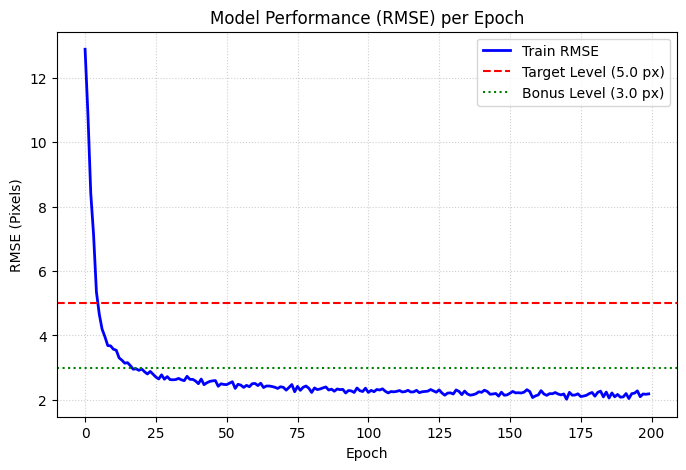

Test RMSE: 1.919 px
Test RMSE: 1.987 px
Test RMSE: 2.073 px
Test RMSE: 2.123 px
Test RMSE: 2.033 px
Test RMSE: 2.067 px
Test RMSE: 2.080 px
Test RMSE: 2.088 px
Test RMSE: 2.073 px
Test RMSE: 2.019 px
-----------------------
Mean RMSE over 10 iterations: 2.05
RMSE standard deviation over 10 iterations: 0.06


In [ ]:
plot_rmse_curve(rmse_history)

RMSEs = np.zeros(10)
for i in range(RMSEs.size):
    set_seed(2**i)
    RMSEs[i] = test_model(net, num_samples=25000)

print("-----------------------")
print(f"Mean RMSE over {int(RMSEs.size)} iterations: {RMSEs.mean():.2f}")
print(f"RMSE standard deviation over {int(RMSEs.size)} iterations: {RMSEs.std():.2f}")


### Function for generating attention heatmaps

The visualize_attention_for_sample function is a diagnostic and visualization tool designed to help understand how the OddNet model processes an input image and how its attention mechanism behaves. For a selected sample from the dataset, the function performs a forward pass through the network, prints the true and predicted coordinates of the odd shape, and then displays four visualizations arranged in a 2×2 grid. Each of these plots highlights a different aspect of the model’s internal reasoning.

The first plot shows the input image itself. This provides a direct reference for interpreting the attention maps. The function also identifies which token (i.e., which receptive field center) is closest to the true label, and this information is included in the title. This helps relate the model’s internal representation to the actual spatial location of the odd shape.

The second plot displays the full 196×196 attention matrix produced by the self‑attention module. Each row corresponds to a query token and each column to a key token. The color intensity indicates how strongly one token attends to another. Although the matrix may appear complex, it often reveals structured patterns such as stripes or blocks, which reflect how tokens interact across the 14×14 spatial grid. This visualization provides a global view of how information flows across the entire image.

The third plot shows the attention map of the token closest to the true odd‑shape location. This is obtained by reshaping the corresponding row of the attention matrix into a 14×14 grid. It reveals where this specific token “looks” when processing the image. In practice, this map typically concentrates around the token’s own receptive field and its immediate neighbors, indicating that the model relies primarily on local information to confirm the presence of the odd shape.

The fourth plot presents the mean attention map, computed by averaging attention weights across all query tokens. This produces a 14×14 heatmap that highlights which regions of the image receive the most attention overall. It provides a global summary of the model’s focus and can reveal whether the network systematically prioritizes certain spatial areas.

Together, these four visualizations offer a comprehensive view of how the model interprets the input image, how attention is distributed across the token grid, and how local and global patterns contribute to the final prediction. The function also returns the input image, the true label, the predicted coordinates, and the index of the token closest to the ground‑truth position, which can be useful for further analysis (which I actually do not do here).

In [ ]:
import matplotlib.pyplot as plt
import torch

def visualize_attention_for_sample(net, dataset, sample_idx=0, device="cpu"):
    # load sample
    img, label = dataset[sample_idx]          # (1,64,64), (2,)
    img_batch = img.unsqueeze(0).to(device)   # (1,1,64,64)

    # forward pass
    net.eval()
    with torch.no_grad():
        pred, attn_weights, _ = net(img_batch)

    print(f"Original label: ({label[0]}, {label[1]})")
    print(f"Prediction label: ({pred[0][0]:.2f}, {pred[0][1]:.2f})")

    A = attn_weights[0].detach().cpu()        # (196,196)

    # find token closest to true label
    centers = net.centers.cpu()               # (196,2)
    dists = torch.sum((centers - label.unsqueeze(0))**2, dim=1)
    token_idx = torch.argmin(dists).item()

    # prepare figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # --- Plot 1: input image ---
    axes[0, 0].imshow(img.squeeze(0), cmap="gray")
    axes[0, 0].set_title(f"Input Image (token {token_idx} closest to label)")
    axes[0, 0].axis("off")

    # --- Plot 2: full attention matrix ---
    im1 = axes[0, 1].imshow(A, cmap="viridis")
    axes[0, 1].set_title("Full Attention Matrix (196x196)")
    fig.colorbar(im1, ax=axes[0, 1])

    # --- Plot 3: attention of selected token ---
    attn_map = A[token_idx].reshape(14, 14)
    im2 = axes[1, 0].imshow(attn_map, cmap="viridis")
    axes[1, 0].set_title(f"Attention Map for Token {token_idx}")
    axes[1, 0].axis("off")
    fig.colorbar(im2, ax=axes[1, 0])

    # --- Plot 4: mean attention ---
    mean_map = A.mean(dim=0).reshape(14, 14)
    im3 = axes[1, 1].imshow(mean_map, cmap="viridis")
    axes[1, 1].set_title("Mean Attention Map (14x14)")
    axes[1, 1].axis("off")
    fig.colorbar(im3, ax=axes[1, 1])

    plt.tight_layout()
    plt.show()

    return img, label, pred.cpu(), token_idx


Original label: (52.0, 55.0)
Prediction label: (51.49, 55.05)


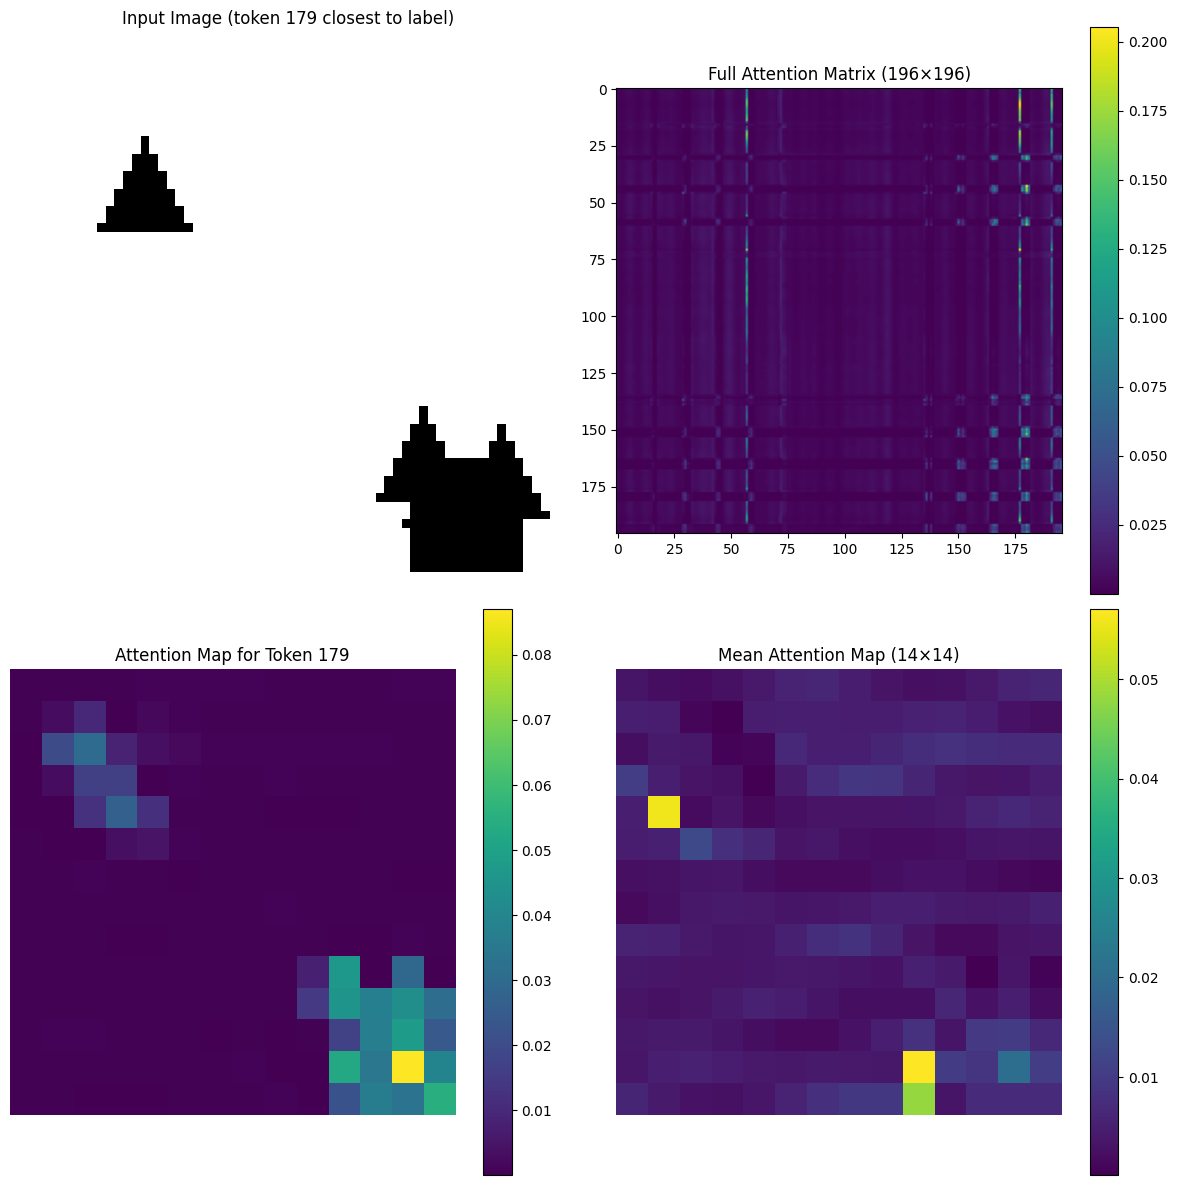

In [ ]:
set_seed(24)
dataset = OddXYDataset(100)

img, label, pred, token_idx = visualize_attention_for_sample(net, dataset, sample_idx=42, device=device)

The figure above presents the attention analysis for sample 42 from the dataset. The model correctly identifies the position of the odd shape, as shown by the close match between the ground‑truth coordinates and the model’s prediction:
- Original label: (52.0, 55.0)
- Predicted position: (51.49, 55.05)

This confirms that the network has learned to localize the odd shape with high precision.

The top‑left panel shows the input image. In this example, the odd shape is located in the lower‑right region of the image. The function automatically identifies the token whose receptive‑field center is closest to the true label; in this case, it is token 179. This token represents the spatial patch that should contain the odd shape, and therefore its attention behavior is particularly informative.

The top‑right panel displays the full 196x196 attention matrix. Although the matrix appears dense, several clear vertical stripes are visible. These stripes correspond to a small number of tokens that receive disproportionately high attention from many other tokens. In practice, these tokens tend to align with the positions of the major shapes visible in the image. This suggests that the model uses these regions as reference points when comparing shapes across the grid. The presence of only a few dominant stripes indicates that the attention mechanism is selective and focuses on the most informative spatial locations.

The bottom‑left panel shows the attention map for token 179, i.e., the token closest to the true odd‑shape position. This map reveals that the token attends primarily to the locations of the other shapes in the image, with the highest focus on itself. This behavior is expected: to determine which shape is the odd one, the model must compare the local patch containing the candidate shape with the patches containing the other shapes. The attention map therefore highlights the regions that the model considers relevant for this comparison.

The bottom‑right panel presents the mean attention map, obtained by averaging attention weights across all tokens. This map shows a similar pattern: the highest attention values cluster around the positions of the shapes. This indicates that the shapes themselves are the primary carriers of information in the image, and the model consistently focuses on them when performing global reasoning. The agreement between the token‑specific attention map and the mean attention map further confirms that the model’s behavior is coherent and interpretable.

Original label: (29.0, 28.0)
Prediction label: (29.35, 27.50)


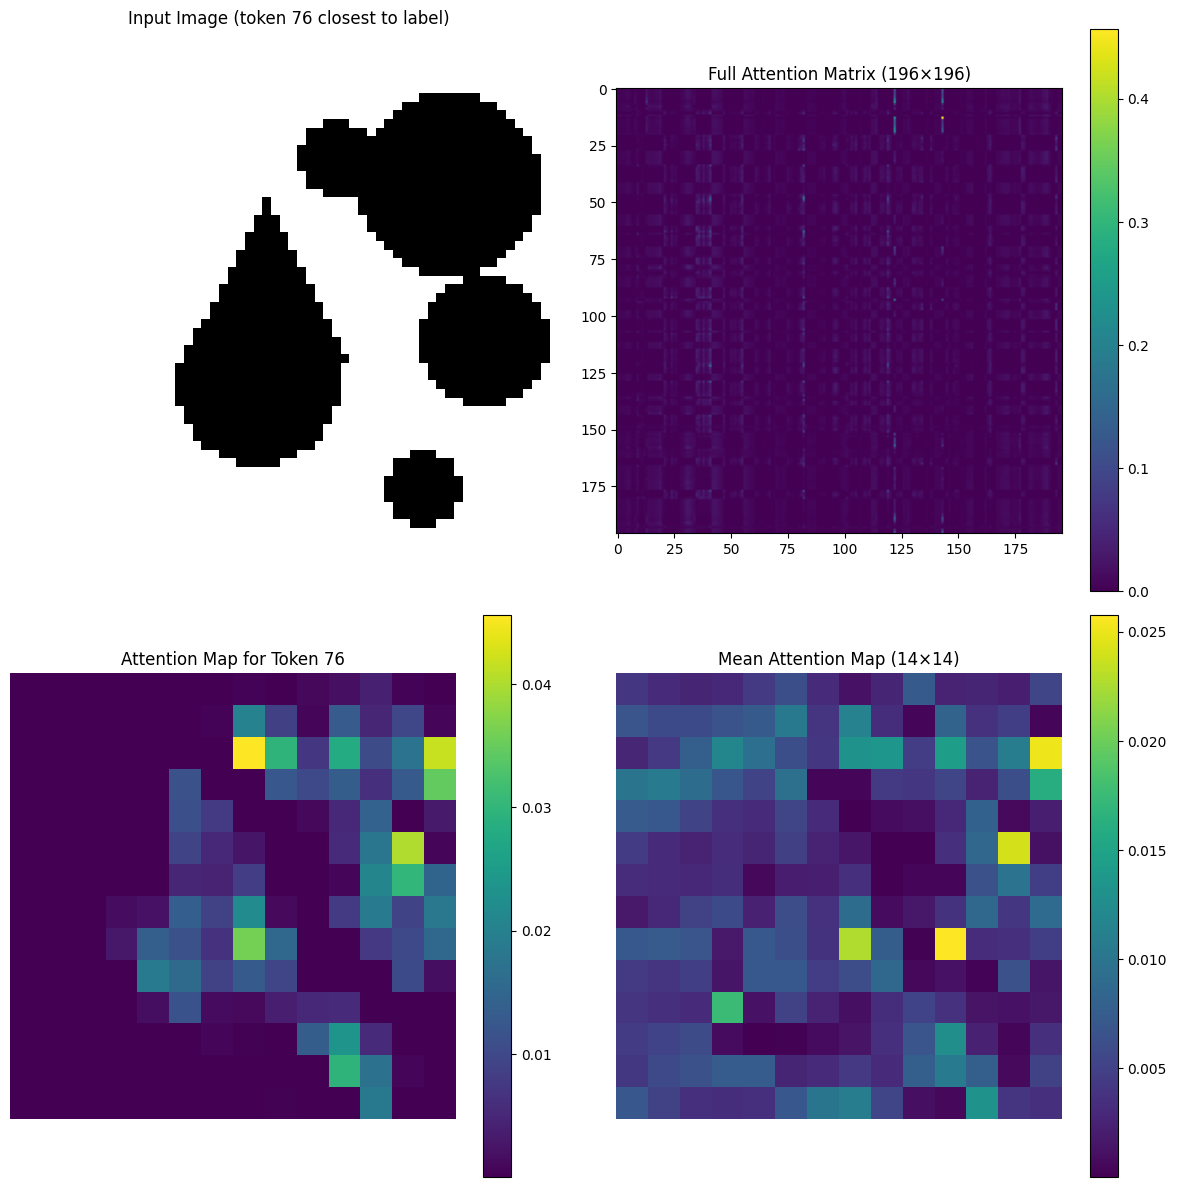

In [ ]:
img, label, pred, token_idx = visualize_attention_for_sample(net, dataset, sample_idx=13, device=device)

For sample 13, the model again predicts the position of the odd shape with high accuracy. The ground‑truth coordinates are (29.0, 28.0), while the model predicts (29.35, 27.50), which is an very good match. In this example, the image contains more shapes than in previous cases, and they are distributed more widely across the canvas. This makes the attention patterns more complex and less localized.

The input image (top‑left panel) shows several shapes scattered across the scene. The function identifies token 76 as the one whose receptive‑field center is closest to the true odd‑shape position. This token is therefore the most relevant for understanding how the model reasons about this particular sample.

The full 196x196 attention matrix (top‑right panel) is noticeably less structured than in earlier examples. Instead of clear stripes or dominant blocks, the matrix appears more diffuse, with only faint grid‑like patterns. This is expected in images where many shapes are present and spread out: the model must compare a larger number of regions, and attention becomes more evenly distributed across tokens. As a result, the global attention map is harder to interpret visually, because no single region dominates the attention flow.

The attention map for token 76 (bottom‑left panel) provides a more meaningful signal. This map shows that the token corresponding to the odd shape attends primarily to the positions of the other shapes in the image. This behavior is consistent with the task: to determine which shape is the odd one, the model must compare the local patch containing the candidate shape with the patches containing the other shapes. The attention map therefore highlights the spatial locations that the model considers relevant for this comparison.

The mean attention map (bottom‑right panel), which averages attention across all tokens, reveals a different pattern. Here, attention is highly dispersed across the entire image. This indicates that, in this particular sample, the model does not rely on a small set of dominant reference points. Instead, many tokens contribute small amounts of attention, reflecting the fact that the shapes are numerous and spread out. The model therefore distributes its focus more uniformly, which is a reasonable strategy given the structure of the input.

Original label: (17.0, 39.0)
Prediction label: (17.80, 40.64)


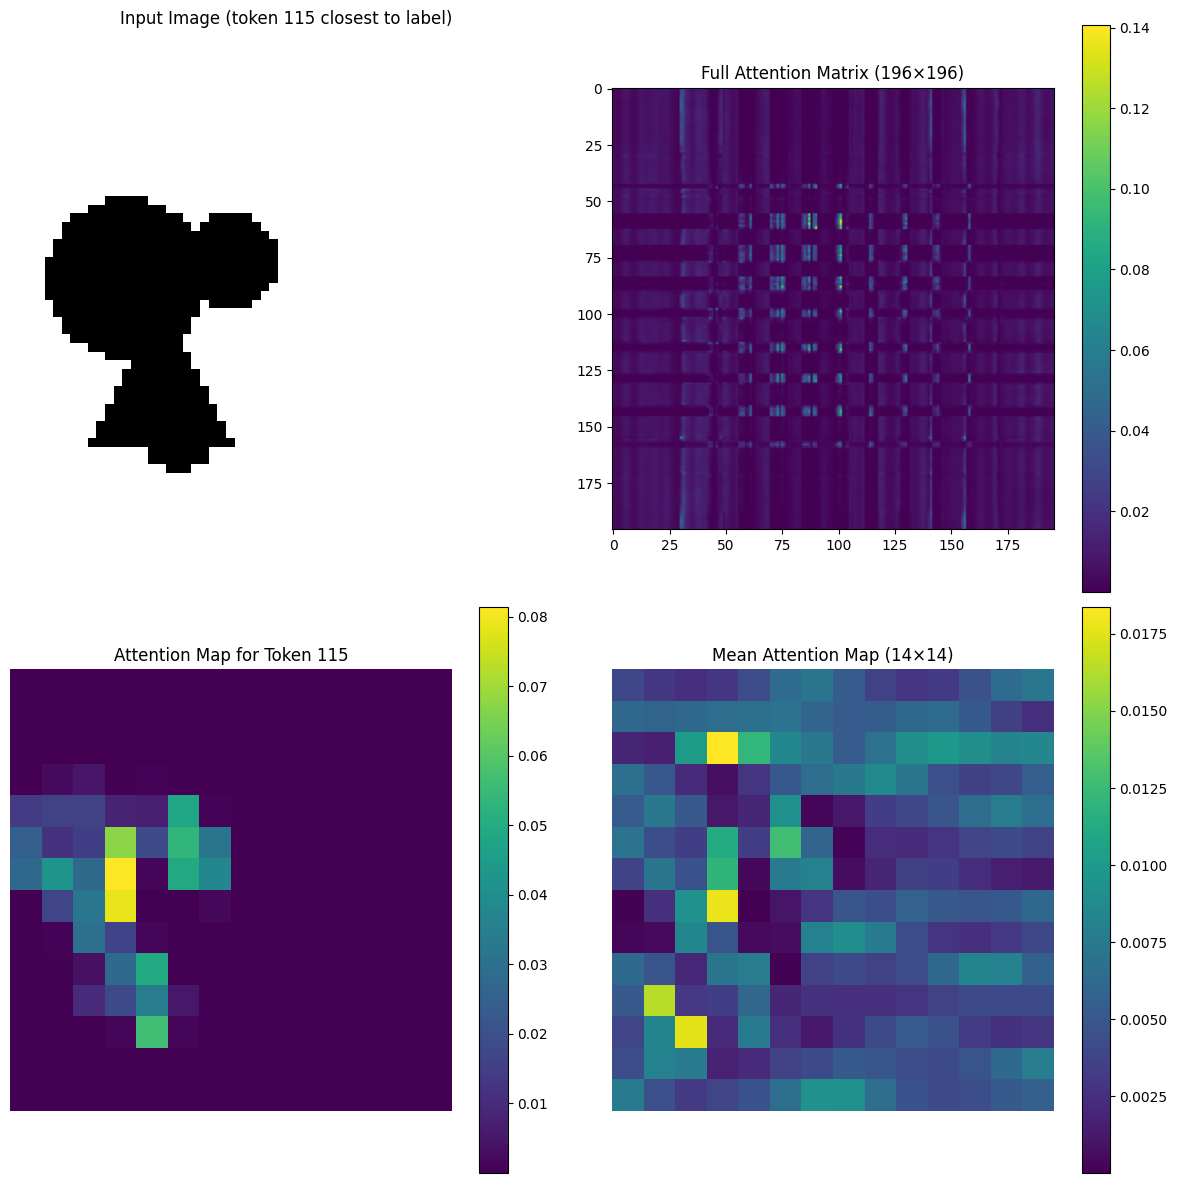

In [ ]:
img, label, pred, token_idx = visualize_attention_for_sample(net, dataset, sample_idx=27, device=device)

For sample 27, the model again predicts the position of the odd shape with high accuracy. The ground‑truth coordinates are (17.0, 39.0), while the model predicts (17.80, 40.64), which is still quite close match. This confirms that the network reliably localizes the odd shape even in images where the shapes are irregular and distributed unevenly.

The input image (top‑left panel) contains several shapes clustered in the central region of the canvas. The function identifies token 115 as the token whose receptive‑field center is closest to the true odd‑shape position. This token is therefore the most relevant for analyzing how the model processes this particular example.

The full 196x196 attention matrix (top‑right panel) shows a pattern that is more diffuse than in simpler examples. Although some vertical structures are visible, the attention is not dominated by a small number of tokens. Instead, the attention weights are spread across many regions of the matrix. This indicates that the model distributes its attention more broadly, likely because the shapes in this sample are not isolated but form a loose cluster. When multiple shapes occupy nearby regions, the model tends to compare many of them simultaneously, which naturally leads to a more dispersed global attention pattern.

The attention map for token 115 (bottom‑left panel) is more informative. This map shows that the token corresponding to the odd shape attends primarily to itself and to the other shapes visible in the image. This is exactly the behavior expected for this task: to determine which shape is the odd one, the model must compare the local patch containing the candidate shape with the patches containing the other shapes. The attention map therefore highlights the spatial locations that the model considers relevant for this comparison.

The mean attention map (bottom‑right panel), which averages attention across all tokens, confirms this interpretation. Although the attention is somewhat dispersed across the entire image, it is still noticeably stronger in the region where the shapes are located. This suggests that the model collectively focuses more on the cluster of shapes than on the empty background, even if no single token dominates the attention distribution

Original label: (32.0, 21.0)
Prediction label: (31.78, 21.17)


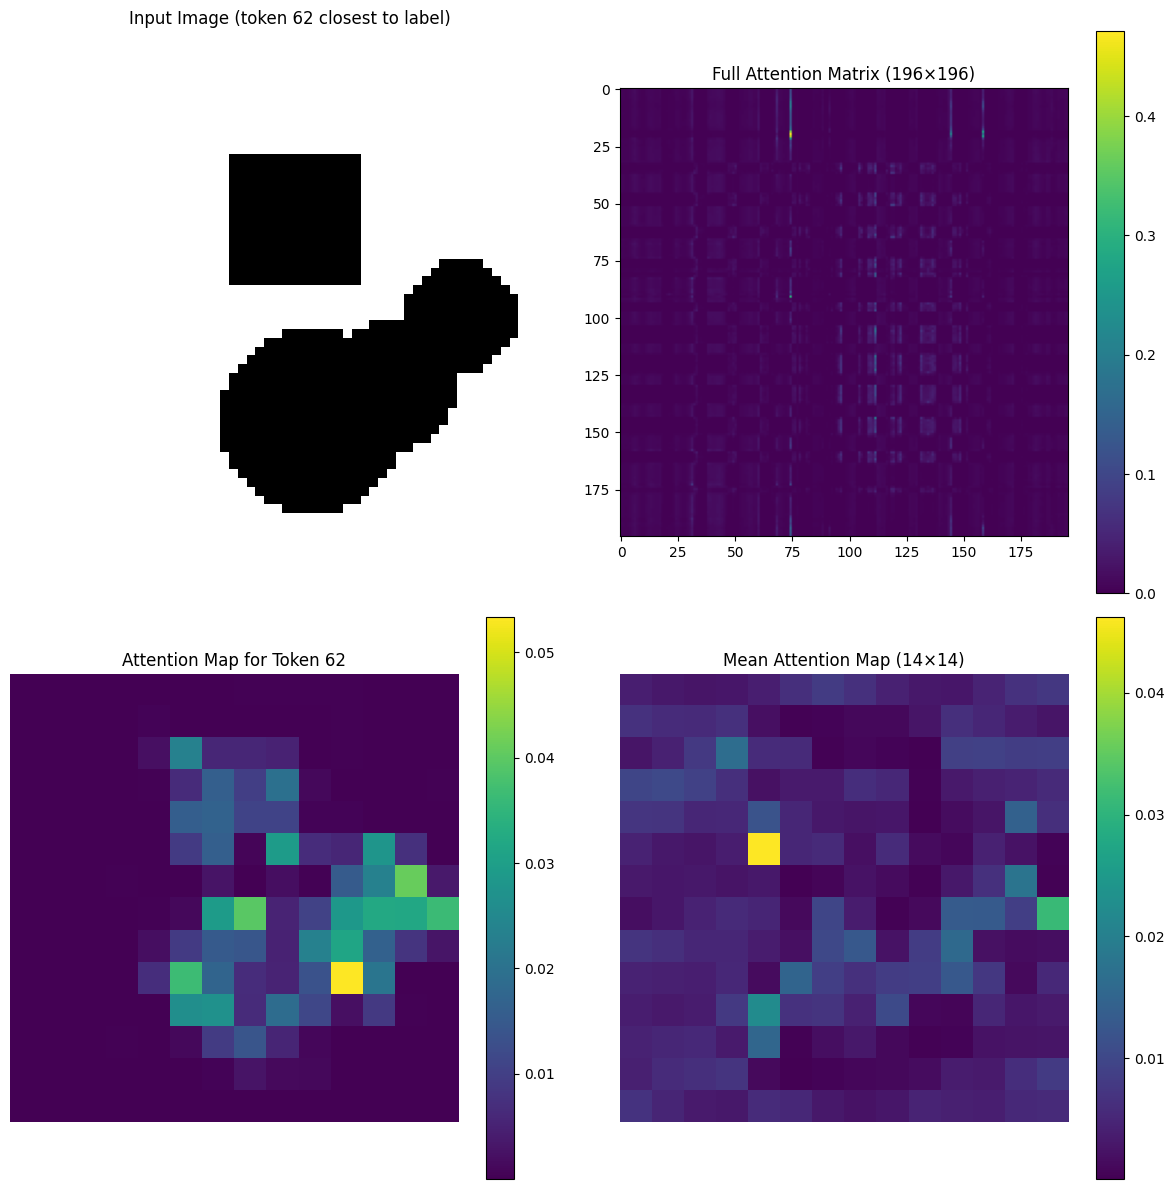

In [ ]:
img, label, pred, token_idx = visualize_attention_for_sample(net, dataset, sample_idx=77, device=device)

For sample 77, the model once again accurately identifies the position of the odd shape.
The ground‑truth coordinates are (32.0, 21.0), and the model predicts (31.78, 21.17), which is an excellent match. This confirms that the network maintains high localization accuracy even in images with only a few shapes and relatively simple spatial structure.

The input image (top‑left panel) contains two shapes: the odd shape and one additional reference shape. The function identifies token 62 as the token whose receptive‑field center is closest to the true odd‑shape position. This token is therefore the most relevant for analyzing how the model processes this example.

The full 196x196 attention matrix (top‑right panel) is difficult to interpret visually. Unlike in examples with many shapes, where clear vertical or horizontal stripes emerge, the attention here is more irregular and lacks strong global structure. This is expected in images with only a small number of shapes: the model has fewer reference points to compare, and the global attention pattern becomes less structured and more diffuse.

The attention map for token 62 (bottom‑left panel) provides a clearer signal. This map shows that the token corresponding to the odd shape attends primarily to the other shape in the image and to itself. Interestingly, the strongest attention is directed toward the center of the cluster formed by the remaining shapes: in this case, the single non‑odd shape. This behavior is consistent with the model’s strategy: to determine whether a shape is the odd one, the token must compare its own local features with those of the other shapes. The attention map therefore highlights the spatial regions that the model considers relevant for this comparison.

The mean attention map (bottom‑right panel) reveals an even more interesting pattern. Unlike in previous examples where the average attention was dispersed or focused on multiple shapes, here the mean attention of all tokens concentrates primarily on the fragment of the odd shape itself. This suggests that, in this particular sample, the odd shape is the most informative region in the entire image. Because the scene contains only two shapes, the model’s global reasoning naturally gravitates toward the one that stands out, resulting in a mean attention map that highlights the odd shape more strongly than the background or the other shape.

Original label: (55.0, 24.0)
Prediction label: (54.55, 23.83)


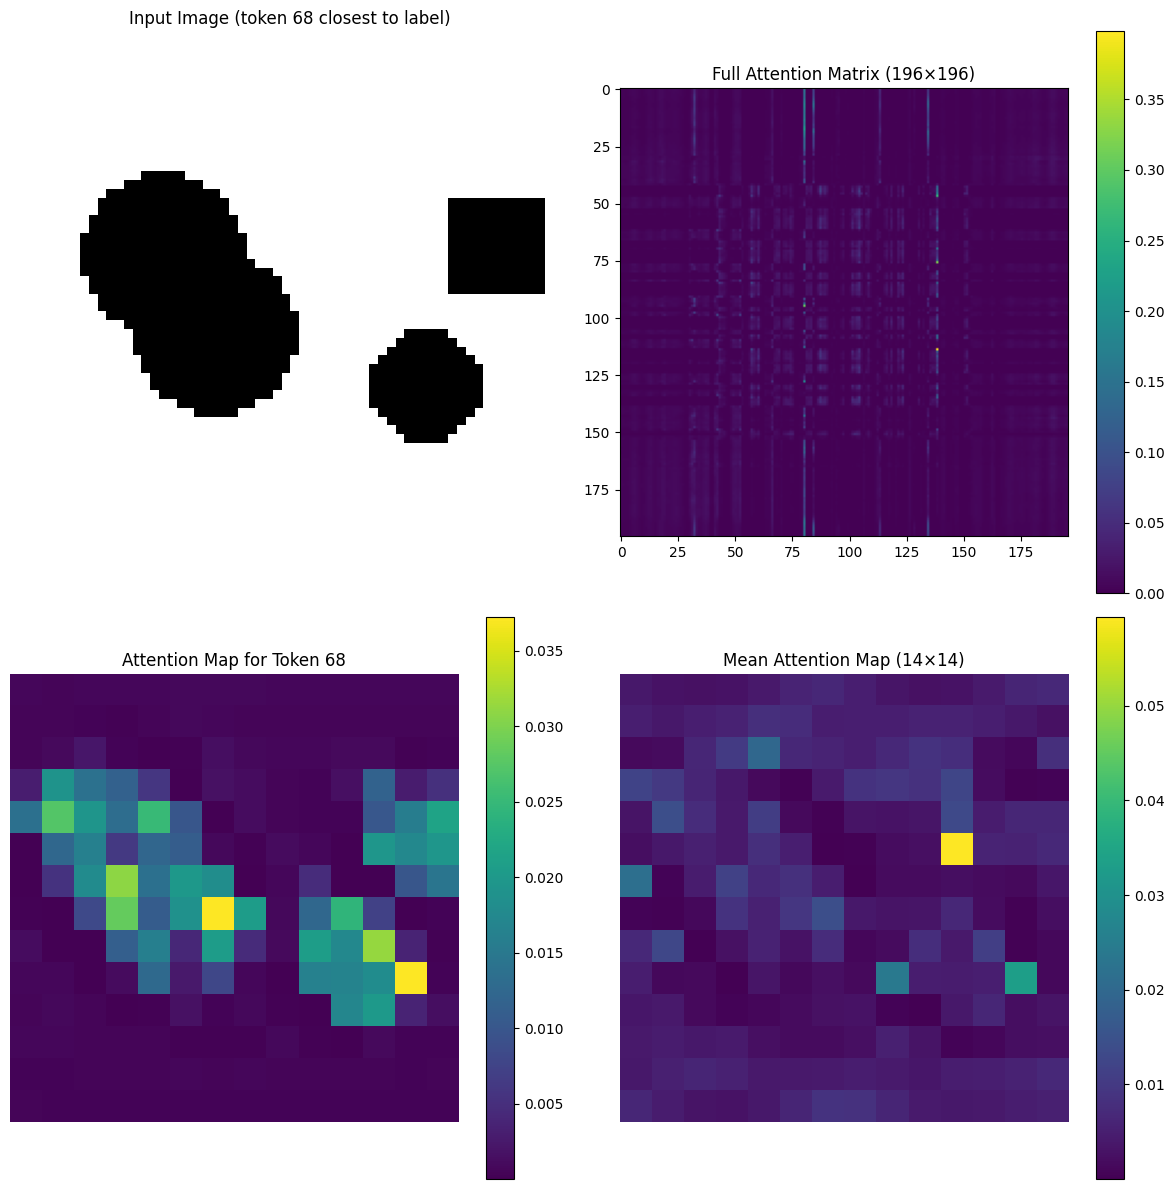

In [ ]:
img, label, pred, token_idx = visualize_attention_for_sample(net, dataset, sample_idx=89, device=device)

For sample 89, the model accurately identifies the position of the odd shape: the ground‑truth coordinates are (55.0, 24.0) and the prediction (54.55, 23.83) is nearly identical. The global 196×196 attention map is difficult to interpret, as the attention is spread across many tokens without a clear dominant structure. The attention map of the token closest to the true odd‑shape position shows that the model focuses mainly on the other shapes and on the odd shape itself, which is consistent with the comparison‑based nature of the task. The mean attention map indicates that, in this example, the overall attention of all tokens also concentrates primarily on the shapes, with a noticeable emphasis on the odd shape.